In [1]:
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ultranest
from ultranest.plot import PredictionBand, cornerplot
import george

In [2]:
urllib.request.urlretrieve(
    "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Global/Land_and_Ocean_summary.txt",
    "Land_and_Ocean_complete_annual.txt"
)
data = np.loadtxt("Land_and_Ocean_complete_annual.txt", comments="%")
columns = [
    "year",
    "annual_anomaly_above", "annual_unc_above",
    "five_year_anomaly_above", "five_year_unc_above",
    "annual_anomaly_below", "annual_unc_below",
    "five_year_anomaly_below", "five_year_unc_below",
]

df = pd.DataFrame(data, columns=columns)

dtype_map = {
    "year": "int",
    "annual_anomaly_above": "float",
    "annual_unc_above": "float",
    "five_year_anomaly_above": "float",
    "five_year_unc_above": "float",
    "annual_anomaly_below": "float",
    "annual_unc_below": "float",
    "five_year_anomaly_below": "float",
    "five_year_unc_below": "float",
}
df = df.astype(dtype_map)

yerr_above = df["annual_unc_above"] / 1.96
yerr_below = df["annual_unc_below"] / 1.96

date = df["year"].values
temp_anomaly = df["annual_anomaly_above"].values
sigma2 = yerr_above ** 2

## Gaussian Processes


In [3]:
# gaussian process model used in every regression (with/whithout trends)
def gp_model(amplitude, length_scale, yerr):
    kernel = amplitude**2 * george.kernels.ExpSquaredKernel(length_scale**2, axes=0)
    gp = george.GP(kernel)
    gp.compute(date.astype(float), yerr)
    return gp


In [4]:
# no trend

def gp_prior(cube):
    params = cube.copy()

    lo_0 = 0.0
    hi_0 = 5.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)

    lo_1 = 0.0
    hi_1 = 100.0
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)

    return params

def log_gp_likelihood(params):
    amp, length = params

    if amp <= 0 or length <= 0:
        return -1e300

    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr_above.to_numpy())
    log_likelihood_value = gp.log_likelihood(temp_anomaly, quiet=True)

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value


parameters_gp = ["amplitude", "length_scale"]

In [5]:
sampler_gp = ultranest.ReactiveNestedSampler(parameters_gp, log_gp_likelihood, gp_prior)
result_gp = sampler_gp.run()
print(result_gp)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=2e+01  21.8107..21.8107]*| it/evals=6360/8895 eff=74.8676% N=400 0          
[ultranest] Likelihood function evaluations: 8940
[ultranest]   logZ = 10.45 +- 0.118
[ultranest] Effective samples strategy satisfied (ESS = 1610.3, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.12, need <0.5)
[ultranest]   logZ error budget: single: 0.16 bs:0.12 tail:0.01 total:0.12 required:<0.50
[ultranest] done iterating.
{'niter': 6788, 'logz': np.float64(10.452990599345563), 'logzerr': np.float64(0.30633148262711746), 'logz_bs': np.float64(10.445584276928786), 'logz_single': np.float64(10.452990599345563), 'logzerr_tail': np.float64(0.009937506498594928), 'logzerr_bs': np.float64(0.3061702520055114), 'ess': np.float64(1610.288892565415), 'H': np.float64(10.34599211136599), 'Herr': np.float64(0.11410954961704607), 'posterior': {'mean': [0.3375450876992805,

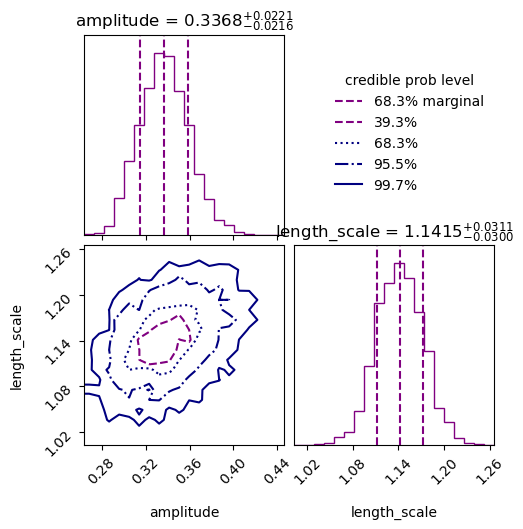

In [6]:
cornerplot(
    result_gp,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.show()
#print(np.exp(result_gp["samples"][0][0]), np.exp(result_gp["samples"][0][1]))

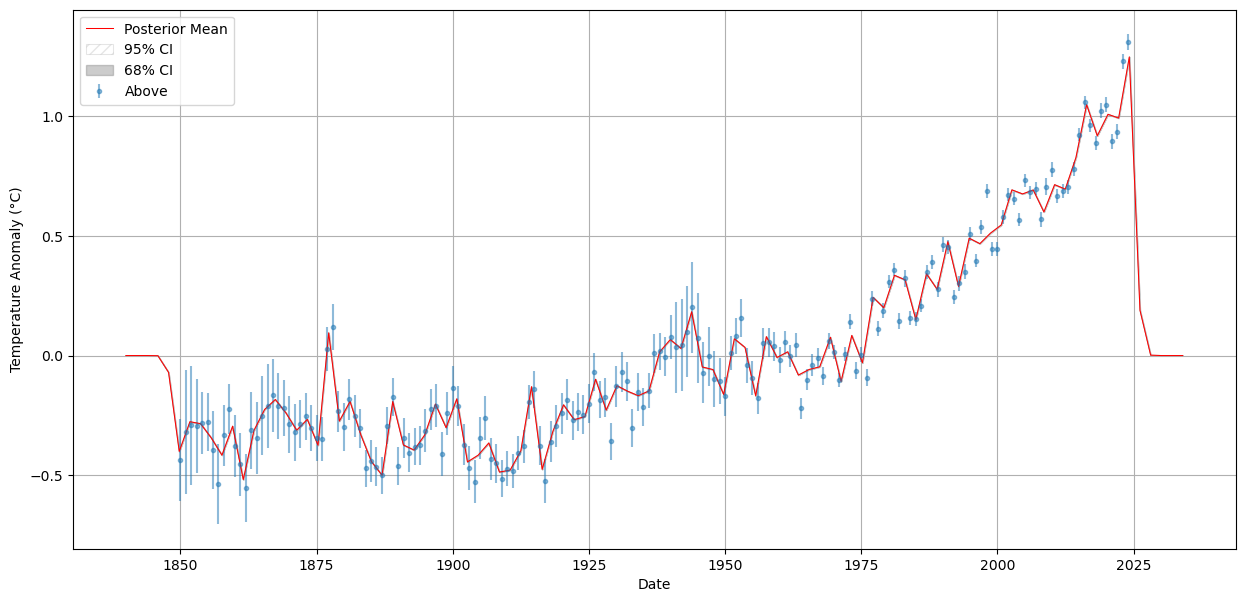

In [7]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min()-10, df["year"].max()+10, 100)
band = PredictionBand(year_range)

gp_m = gp_model(amplitude=result_gp["samples"][0][0], length_scale=result_gp["samples"][0][1], yerr=yerr_above.to_numpy())

for params in result_gp["samples"]:
    amp, length = params
    band.add(gp_m.predict(temp_anomaly, year_range.astype(float), return_cov=False))

band.line(color="red", label="Posterior Mean", linewidth=0.75)
band.shade(color="gray", label="95% CI", q=0.475, alpha=0.2, hatch="///", edgecolor="gray", facecolor="none", linewidth=0.75)
band.shade(color="gray", label="68% CI", q=0.16, alpha=0.4)

plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [8]:
def linear_trend(x, intercept, slope):
    return intercept + slope * x

def gp_linear_prior(cube):
    params = np.empty_like(cube)
    
    lo_0 = -2000.0
    hi_0 = 2000.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)

    lo_1 = -5.
    hi_1 = 5.
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)

    lo_2 = 1e-3
    hi_2 = 10.0
    params[2] = lo_2 + cube[2] * (hi_2 - lo_2)

    lo_3 = 1e-5
    hi_3 = 200.0
    params[3] = lo_3 + cube[3] * (hi_3 - lo_3)

    return params

def log_gp_likelihood(params):
    intercept, slope, amp, length = params

    if amp <= 0 or length <= 0:
        return -1e300

    trend = linear_trend(date, intercept, slope)
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr_above.to_numpy())
    log_likelihood_value = gp.log_likelihood(temp_anomaly - trend, quiet=True)

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value

parameters_gp = ["trend_intercept", "trend_slope", "amplitude", "length_scale"]

In [9]:
sampler_linear_gp = ultranest.ReactiveNestedSampler(parameters_gp, log_gp_likelihood, gp_linear_prior)
result_linear_gp = sampler_linear_gp.run()
print(result_linear_gp)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=9e+01  86.7451..86.7452]*| it/evals=15503/49927 eff=31.3021% N=400 0            0  0 0  
[ultranest] Likelihood function evaluations: 49967
[ultranest]   logZ = 52.54 +- 0.1956
[ultranest] Effective samples strategy satisfied (ESS = 2129.9, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.20, need <0.5)
[ultranest]   logZ error budget: single: 0.28 bs:0.20 tail:0.01 total:0.20 required:<0.50
[ultranest] done iterating.
{'niter': 15919, 'logz': np.float64(52.6107729280964), 'logzerr': np.float64(0.34992232782536087), 'logz_bs': np.float64(52.54429410237761), 'logz_single': np.float64(52.6107729280964), 'logzerr_tail': np.float64(0.009929575381917743), 'logzerr_bs': np.float64(0.3497814160921848), 'ess': np.float64(2129.920317245858), 'H': np.float64(32.28520103315238), 'Herr': np.float64(0.19944753165621257), 'posterior': {'mean': [-13.88318

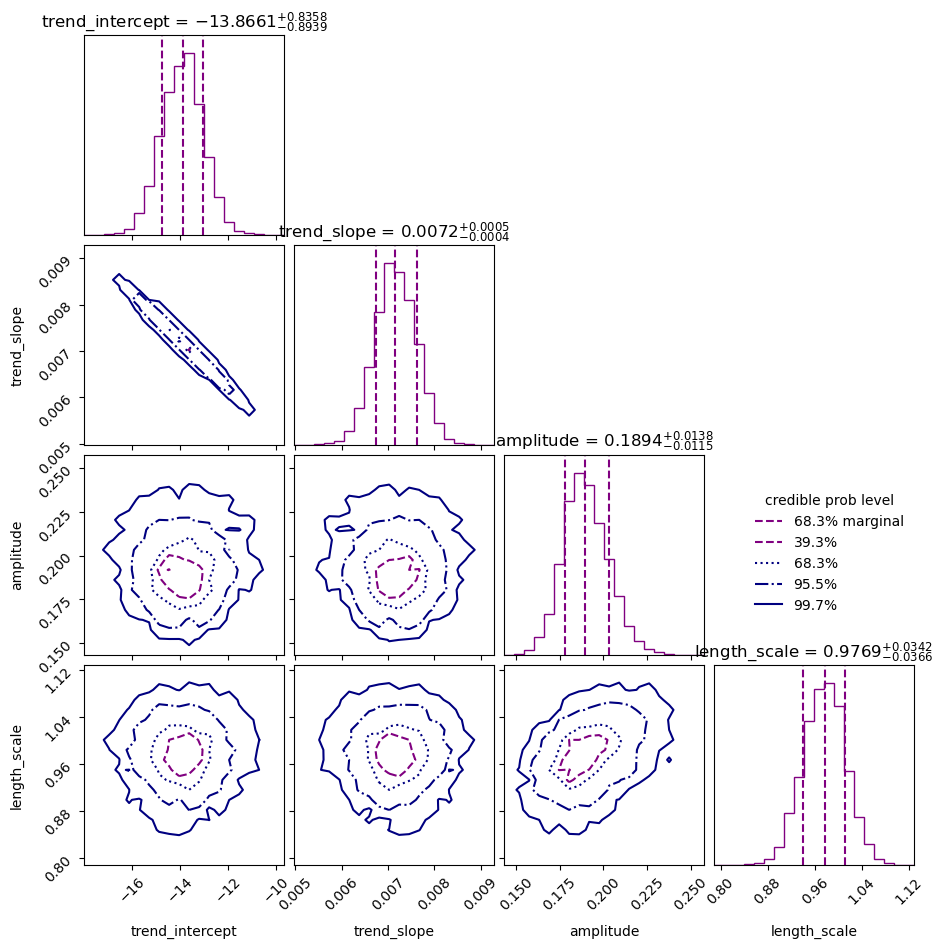

In [10]:
cornerplot(
    result_linear_gp,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.show()

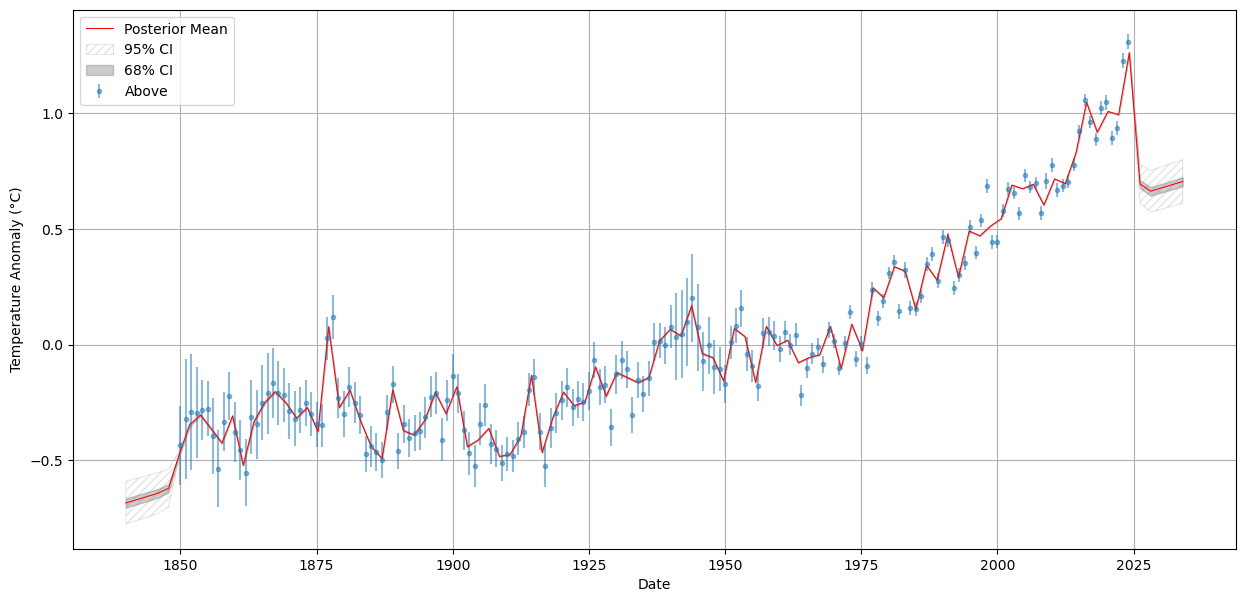

In [11]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min() - 10, df["year"].max() + 10, 100)
band = PredictionBand(year_range)

yerr = yerr_above.to_numpy()

for params in result_linear_gp["samples"]:
    intercept, slope, amp, length = params
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr)
    trend_obs = linear_trend(date, intercept, slope)
    trend_pred = linear_trend(year_range, intercept, slope)
    gp_mean = gp.predict(temp_anomaly - trend_obs, year_range.astype(float), return_cov=False, return_var=False)
    band.add(gp_mean + trend_pred)

band.line(color="red", label="Posterior Mean", linewidth=0.75)
band.shade(color="gray", label="95% CI", q=0.475, alpha=0.2, hatch="////", edgecolor="gray", facecolor="none", linewidth=0.75)
band.shade(color="gray", label="68% CI", q=0.16, alpha=0.4)

plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()


In [12]:
def exponential_trend(x, q, a, m):
    t = (np.asarray(x) - 1950.0) / 50.0
    return q + a * np.exp(m * t)

def gp_prior(cube):
    params = cube.copy()

    lo_0 = -2.0
    hi_0 = 2.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)

    lo_1 = -2.0
    hi_1 = 2.0
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)

    lo_2 = -4.0
    hi_2 = 4.0
    params[2] = lo_2 + cube[2] * (hi_2 - lo_2)

    lo_3 = 1e-3
    hi_3 = 10.0
    params[3] = lo_3 + cube[3] * (hi_3 - lo_3)

    lo_4 = 1e-5
    hi_4 = 200.0
    params[4] = lo_4 + cube[4] * (hi_4 - lo_4)

    return params

def log_gp_likelihood(params):
    q, a, m, amp, length = params

    if amp <= 0 or length <= 0:
        return -1e300

    trend = exponential_trend(date, q, a, m)
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr_above.to_numpy())
    log_likelihood_value = gp.log_likelihood(temp_anomaly - trend, quiet=True)

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value

parameters_gp = ["trend_q", "trend_a", "trend_m", "amplitude", "length_scale"]

In [13]:
sampler_exp_gp = ultranest.ReactiveNestedSampler(parameters_gp, log_gp_likelihood, gp_prior)
result_exp_gp = sampler_exp_gp.run()
print(result_exp_gp)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=1e+02  5 [140.1776..140.1780]*| it/evals=12800/198378 eff=6.4654% N=400    0  
[ultranest] Likelihood function evaluations: 198434
[ultranest]   logZ = 112.7 +- 0.2166
[ultranest] Effective samples strategy satisfied (ESS = 2409.6, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.19 to 0.60, need <0.5)
[ultranest]   logZ error budget: single: 0.25 bs:0.22 tail:0.01 total:0.22 required:<0.50
[ultranest] done iterating.
{'niter': 13219, 'logz': np.float64(112.82721122005645), 'logzerr': np.float64(0.23496665882354947), 'logz_bs': np.float64(112.7301270407659), 'logz_single': np.float64(112.82721122005645), 'logzerr_tail': np.float64(0.009945483019706103), 'logzerr_bs': np.float64(0.23475608219214905), 'ess': np.float64(2409.563223465415), 'H': np.float64(25.037373295367686), 'Herr': np.float64(0.20711214863348243), 'post

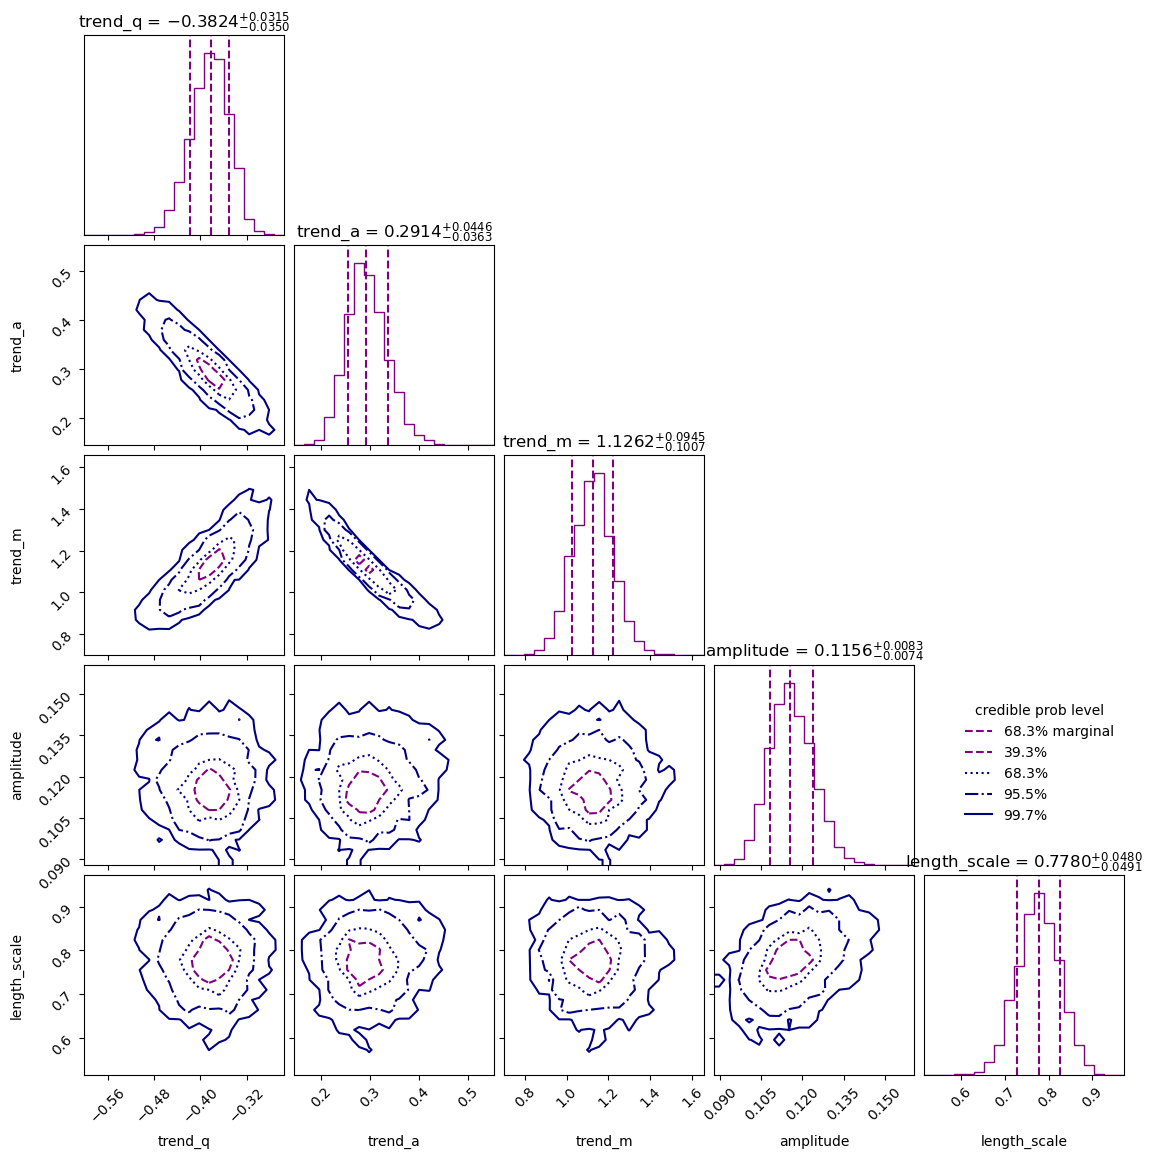

In [14]:
cornerplot(
    result_exp_gp,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.show()

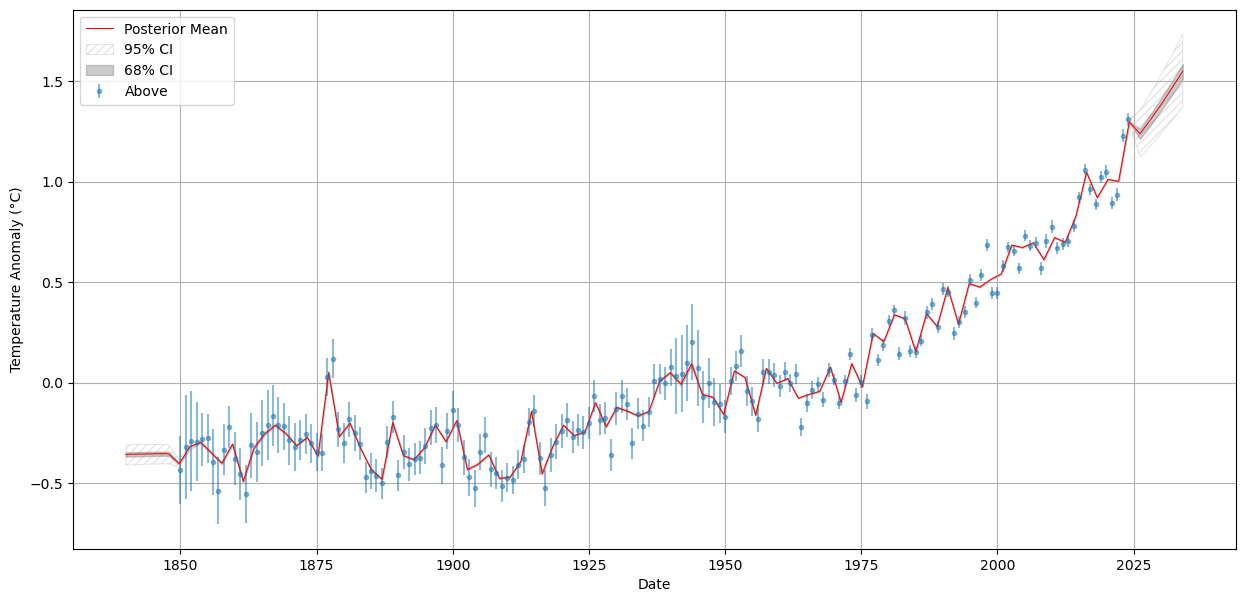

In [15]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min() - 10, df["year"].max() + 10, 100)
band = PredictionBand(year_range)

yerr = yerr_above.to_numpy()

for params in result_exp_gp["samples"]:
    q, a, m, amp, length = params
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr)
    trend_obs = exponential_trend(date, q, a, m)
    trend_pred = exponential_trend(year_range, q, a, m)
    gp_mean = gp.predict(temp_anomaly - trend_obs, year_range.astype(float), return_cov=False, return_var=False)
    band.add(gp_mean + trend_pred)

band.line(color="red", label="Posterior Mean", linewidth=0.75)
band.shade(color="gray", label="95% CI", q=0.475, alpha=0.2, hatch="////", edgecolor="gray", facecolor="none", linewidth=0.75)
band.shade(color="gray", label="68% CI", q=0.16, alpha=0.4)

plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()


In [16]:
# save results to file
import pickle
from pathlib import Path

In [17]:
out_dir = Path("results")
out_dir.mkdir(exist_ok=True)

to_save = {
    "result_gp": result_gp,
    "result_linear_gp": result_linear_gp,
    "result_exp_gp": result_exp_gp,
}

with open(out_dir / "gp_results.pkl", "wb") as f:
    pickle.dump(to_save, f)

# to load later:
#with open("results/gp_results.pkl", "rb") as f:
#    results = pickle.load(f)
#
#result_gp = results["result_gp"]
#result_linear_gp = results["result_linear_gp"]
#result_exp_gp = results["result_exp_gp"]